**📊Modelo Predictivo de Salarios en cargos de DataScience+**

**🎯 Objetivo**

Desarrollar un modelo de Machine Learning capaz de estimar el salario anual de una posición de Data Science basándose en las características del empleo (nivel de seniority, modalidad de trabajo, sector industrial) y el perfil técnico requerido (habilidades). El proyecto busca transformar datos crudos de portales de empleo en una herramienta analítica que permita a profesionales, reclutadores o analistas de mercado comprender cómo se valoran las distintas variables en el mercado laboral actual

**⚠️ Problema que resuelve**

- ***Para las empresas:*** Ayuda a estructurar bandas salariales competitivas según las exigencias técnicas y el nivel de seniority requerido.

- ***Para el candidato:***: Permite evaluar si una oferta de trabajo está ofreciendo un salario competitivo acorde a sus habilidades y al mercado.

- ***Para el mercado:*** Permite identificar brechas salariales o el "valor de mercado" real de habilidades específicas (ej: ¿cuánto paga el mercado extra por saber Python frente a solo SQL?).


**💾 3. DatasetVolumen:** El archivo contiene  944 ofertas de trabajo relacionadaso con puestos de DataScience en diferentes empresas, entre 2024-2025.

https://www.kaggle.com/datasets/nalisha/data-science-careers-and-salaries-2025


**🎯 Variable Objetivo (Target)**

`salary` (Salario).

**📖 Diccionario de Datos**

| **Columna** | **Tipo** | **Descripción** | **Ejemplo**|
| :--- | :--- | :--- | :---|
| `job_title` | String | Título del puesto de trabajo | Data Science|
| `seniority_level` | Categorical | Nivel de experiencia requerido | Senior, Lead, Junior |
| `status` | Categorica | Modalidad de trabajo | On-site, Hybrid, Remote |
| `company` | String | Nombre de la empresa (codificado) | company_003 |
| `location` | String | Ubicación del puesto | New York, Remote |
| `post_date` | Date/Time | Tiempo transcurrido desde la publicación | 2 days ago |
| `Headquarters` | String | Ubicación de la sede central | San Francisco, CA |
| `Industry` | Categorical | Sector industrial de la empresa | Technology, Finance |
| `ownership` | Categorical | Tipo de empresa | Public, Private |
| `company_size` | Categorical | Rango de número de empleados | 1000-5000 employees |
| `Revenue` | Numeric/String | Ingresos anuales de la empresa | usd 10 billones  |
| `salary` | String | Detalle del salario (rango o fijo) | usd 80,000 - 120,000 |
| `skills` | List/Text | Habilidades técnicas requeridas | Python, SQL, Machine Learning |


# <font color='1890A3'>**SECCION 1. CARGA Y PRIMERA EXPLORACION**
**Cargar el dataset | head | tail | info | describe | shape** </font>

>## <font color='1890A3'>**Paso 1.1 Configuracion e importaciones** </font>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re

warnings.filterwarnings('ignore')

# Configuración de estilos
plt.rcParams.update({
    'figure.facecolor': '#0F0F1A', 'axes.facecolor': '#1A1A2E',
    'axes.edgecolor': '#444',      'axes.labelcolor': '#CCC',
    'xtick.color': '#AAA',         'ytick.color': '#AAA',
    'text.color': 'white',         'grid.color': '#333',
    'grid.linestyle': '--',        'legend.facecolor': '#1A1A2E',
    'legend.edgecolor': '#444',
})

# Paleta de colores para gráficos posteriores
PURPLE = '#6C3CE1'
TEAL   = '#00C9A7'
AMBER  = '#F59E0B'
RED    = '#E44D26'

> ## <font color='1890A3'>**Paso 1.2 Cargar el dataset**</font>

In [ ]:
df = pd.read_csv('/content/sample_data/data_science_job_posts_2025.csv')

print(f'Dataset cargado exitosamente!')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria aproximada: {df.memory_usage(deep=True).sum() / 1024:.0f} KB')
print(f'\nColumnas: {list(df.columns)}')

Dataset cargado exitosamente!
Dimensiones: 944 filas x 13 columnas
Memoria aproximada: 788 KB

Columnas: ['job_title', 'seniority_level', 'status', 'company', 'location', 'post_date', 'headquarter', 'industry', 'ownership', 'company_size', 'revenue', 'salary', 'skills']


> ## <font color='1890A3'>**Paso 1.3 Primeras y Ultimas filas del Dataset**</font>

In [ ]:
print('=== Primeras 5 filas ===')
display(df.head())
print('\n=== Ultimas 5 filas ===')
display(df.tail())

=== Primeras 5 filas ===


,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
0,data scientist,senior,hybrid,company_003,"Grapevine, TX . Hybrid",17 days ago,"Bentonville, AR, US",Retail,Public,€352.44B,Public,"€100,472 - €200,938","['spark', 'r', 'python', 'scala', 'machine lea..."
1,data scientist,lead,hybrid,company_005,"Fort Worth, TX . Hybrid",15 days ago,"Detroit, MI, US",Manufacturing,Public,"155,030",€51.10B,"€118,733","['spark', 'r', 'python', 'sql', 'machine learn..."
2,data scientist,senior,on-site,company_007,"Austin, TX . Toronto, Ontario, Canada . Kirkla...",a month ago,"Redwood City, CA, US",Technology,Public,"25,930",€33.80B,"€94,987 - €159,559","['aws', 'git', 'python', 'docker', 'sql', 'mac..."
3,data scientist,senior,hybrid,company_008,"Chicago, IL . Scottsdale, AZ . Austin, TX . Hy...",8 days ago,"San Jose, CA, US",Technology,Public,"34,690",€81.71B,"€112,797 - €194,402","['sql', 'r', 'python']"
4,data scientist,NaN,on-site,company_009,On-site,3 days ago,"Stamford, CT, US",Finance,Private,"1,800",Private,"€114,172 - €228,337",[]



=== Ultimas 5 filas ===


,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
939,data scientist,senior,NaN,company_171,"Bengaluru, Karnataka, India",a day ago,"Armonk, NY, US",Technology,Public,"524,598",€120.29B,"€33,288 - €53,080","['pytorch', 'python', 'sql', 'machine learning..."
940,machine learning engineer,senior,NaN,company_134,"Melbourne, Victoria, Australia",a month ago,"Seattle, WA, US",Retail,Public,"865,456",€838.78B,"€64,290","['amazon', 'machine learning']"
941,data scientist,midlevel,on-site,company_395,"McLean, VA",11 days ago,"McLean, VA, US",Retail,Public,"55,150",€36.29B,"€145,904 - €166,510","['spark', 'aws', 'r', 'python', 'scala', 'sql'..."
942,data scientist,midlevel,on-site,company_395,"New York, NY",17 days ago,"McLean, VA, US",Retail,Public,"55,110",€36.34B,"€159,149 - €181,595","['spark', 'aws', 'r', 'python', 'scala', 'sql'..."
943,data scientist,senior,on-site,company_844,"San Diego, CA",8 days ago,"Mountain View, CA, US",Technology,Public,"17,040",€95.22B,"€195,486 - €201,926","['r', 'python', 'scala', 'sql', 'machine learn..."


> ## <font color='1890A3'>**Paso 1.4 Estructura General del Dataset**</font>

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   job_title        941 non-null    object
 1   seniority_level  884 non-null    object
 2   status           688 non-null    object
 3   company          944 non-null    object
 4   location         942 non-null    object
 5   post_date        944 non-null    object
 6   headquarter      944 non-null    object
 7   industry         944 non-null    object
 8   ownership        897 non-null    object
 9   company_size     944 non-null    object
 10  revenue          929 non-null    object
 11  salary           944 non-null    object
 12  skills           944 non-null    object
dtypes: object(13)
memory usage: 96.0+ KB


Nulos en las columnas `job_title`, `seniority_level`, `status`, `ownership` y `revenue` probablemnete los anuncios no incluian esa informacion de manera explicita.
13 columnas, todas tipo object, `salary` y `company_size` deberian ser numericos y otras commo `industry` y `ownership` categoricos.0

> ## <font color='1890A3'>**Paso 1.5 Estadisticas Descriptivas del Dataset**</font>

In [ ]:
df.describe()


,job_title,seniority_level,status,company,location,post_date,headquarter,industry,ownership,company_size,revenue,salary,skills
count,941,884,688,944,942,944,944,944,897,944,929,944,944
unique,4,4,3,420,431,42,197,8,2,510,312,896,400
top,data scientist,senior,on-site,company_134,"Bengaluru, Karnataka, India",a month ago,"San Francisco, CA, US",Technology,Public,900,Private,"€114,169",[]
freq,856,630,363,30,52,167,91,582,579,18,247,3,201


`salary` tiene valores en numeros y algunos con el simbolo de la moneda Euros

`location` tiene 431 ubicaciones distintas, alta cardinalidad.

La fila top indica que la categoría que más se repite en `industry` es "Technology", en `seniority_level` es "senior" y en `status` es "on-site".

 `skills` tiene 400 valores únicos y, en algunos casos, contiene listas vacías [].

# <font color='1890A3'>**SECCION 2. LIMPIEZA DE DATOS**
**tipos | duplicados | inconsistencias | nulos | outliers** </font>

> ## <font color='1890A3'>**Paso 2.1 Verificar y corregir tipos de datos**</font>

In [ ]:
print('Tipos de Datos ANTES de limpiar:')
print(df.dtypes)
print()

Tipos de Datos ANTES de limpiar:
job_title          object
seniority_level    object
status             object
company            object
location           object
post_date          object
headquarter        object
industry           object
ownership          object
company_size       object
revenue            object
salary             object
skills             object
dtype: object



In [ ]:
def convert_and_clean(value):
    if pd.isna(value) or value == '':
        return np.nan
    val_str = str(value)
    exchange_rate = 1.16
    is_euro = '€' in val_str
    clean_str = val_str.replace('€', '').replace('$', '').replace(',', '')
    multiplier = 1
    if 'B' in clean_str.upper():
        multiplier = 1_000_000_000
    elif 'M' in clean_str.upper():
        multiplier = 1_000_000
    elif 'k' in clean_str.lower():
        multiplier = 1_000

    numbers = re.findall(r"[\d\.]+", clean_str)
    numbers = [float(n) for n in numbers]

    if not numbers:
        return np.nan
    avg_value = np.mean(numbers) * multiplier
    return avg_value * exchange_rate if is_euro else avg_value

df['salary'] = df['salary'].apply(convert_and_clean)
df['revenue'] = df['revenue'].apply(convert_and_clean)
df['salary'] = pd.to_numeric(df['salary'], errors='coerce')
df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')

In [ ]:
# Columnas a categóricas
cat_cols = ['seniority_level', 'status', 'industry', 'ownership', 'company_size']
for col in cat_cols:
    df[col] = df[col].astype('category')

In [ ]:
# Conversión de fecha
df['post_date'] = pd.to_datetime(df['post_date'], errors='coerce')

In [ ]:
# Skills: convertir a string y limpiar las listas vacias (corchetes), y convertir el texto en una lista de habilidades
df['skills'] = df['skills'].astype(str)
df['skills'] = df['skills'].str.replace(r"[\[\]']", "", regex=True)
df['skills'] = df['skills'].str.split(', ')
print(df['skills'].head())


0    [spark, r, python, scala, machine learning, te...
1            [spark, r, python, sql, machine learning]
2    [aws, git, python, docker, sql, machine learni...
3                                     [sql, r, python]
4                                                   []
Name: skills, dtype: object


In [ ]:
print('Tipos de Datos DESPUES de limpiar:')
print(df.dtypes)
print()

Tipos de Datos DESPUES de limpiar:
job_title                  object
seniority_level          category
status                   category
company                    object
location                   object
post_date          datetime64[ns]
headquarter                object
industry                 category
ownership                category
company_size             category
revenue                   float64
salary                    float64
skills                     object
dtype: object



> ## <font color='1890A3'>**Paso 2.2 Identificar y eliminar duplicados**</font>

In [ ]:
# excluyo la columna skills, ya que varias ofertas pueden requerir las mismas skills
df_clean = df.copy()
n_total = len(df_clean)
n_dupes = df_clean.drop(columns=['skills']).duplicated().sum()

print(f'Filas totales:           {n_total}')
print(f'Duplicados exactos:      {n_dupes} ({n_dupes/n_total*100:.1f}%)')

Filas totales:           944
Duplicados exactos:      1 (0.1%)


> ## <font color='#1890A3'> **Paso 2.3 Inconsistencias en valores categoricos** </font>

In [ ]:
columnas_categoricas = ['seniority_level', 'status', 'industry', 'ownership', 'company_size', 'location', 'job_title']

for columna in columnas_categoricas:
  df_clean[columna] = df_clean[columna].str.strip().str.title()
  valores_unicos = df_clean[columna].unique()
  print(f"• Columna '{columna}' ({len(valores_unicos)} categorías únicas):")
  print(f"  -> {valores_unicos}\n")

# Para skills que es una lista
valores_unicos = set(skill for sublist in df['skills'] for skill in sublist)
print(valores_unicos)

• Columna 'seniority_level' (5 categorías únicas):
  -> ['Senior' 'Lead' nan 'Junior' 'Midlevel']

• Columna 'status' (4 categorías únicas):
  -> ['Hybrid' 'On-Site' nan 'Remote']

• Columna 'industry' (8 categorías únicas):
  -> ['Retail' 'Manufacturing' 'Technology' 'Finance' 'Education' 'Healthcare'
 'Energy' 'Logistics']

• Columna 'ownership' (3 categorías únicas):
  -> ['Public' 'Private' nan]

• Columna 'company_size' (510 categorías únicas):
  -> ['€352.44B' '155,030' '25,930' '34,690' '1,800' '150' '17,471' '900' '126'
 '5,520' '103,010' '240' '21,030' '128,890' '45' '300' '132,000' '257,150'
 '130' '93,580' '44,010' '11,610' '100' '222,070' '340' '3,780' '807'
 '8,010' '26,950' '4,820' '157,200' '1,320' '4,780' '26,070' '1,790'
 '5,260' '210' '9,070' '9,030' '60' '41,020' '26,040' '5,050' '990'
 '2,290' '3,810' '24,040' '46' '330' '5' '950' '750' '23,860' '28,840'
 '10,933' '99,620' '38,090' '2,300' '420' '118,910' '68,400' '187,540'
 '17,451' '1,290' '28,810' '5,320' '30' '5

In [ ]:
# skills, eliminar los elementos ' '
df_clean['skills'] = df['skills'].apply(lambda lista: [s for s in lista if s.strip() != ''])

# Company_size, eliminar valores numemricos y sustituyo por Nan
def clean_size(val):
    val = str(val)
    if '€' in val or 'B' in val:
        return np.nan
    return pd.to_numeric(val.replace(',', ''), errors='coerce')

df_clean['company_size'] = df_clean['company_size'].apply(clean_size)


In [ ]:
#Location, tiene info del status -> eliminar, algunos registros con ciudad, pais, estado  y otros solo con pais -> organizar

# eliminar datos de status
modalidades = ['hybrid', 'on-site', 'remote', 'fully remote']
def extract_status(row):
    loc_raw = str(row['location']).lower()
    stat_raw = str(row['status']).lower()
    if pd.isna(row['status']) or stat_raw == 'nan':
        for mod in modalidades:
            if mod in loc_raw:
                return 'remote' if 'remote' in mod else mod
        return 'on-site'
    if 'remote' in stat_raw: return 'remote'
    return stat_raw

df_clean['status'] = df_clean.apply(extract_status, axis=1)

# extraemos y buscamos el pais y agrupamos por region

def clean_and_classify_strict(loc):
    loc_original = str(loc).lower()
    grupos = {
        'norteamerica': ['usa', 'us', 'united states', 'estados unidos', 'america', 'canada', 'new york', 'san francisco',
                         'chicago', 'toronto', 'california', 'texas', 'los angeles', 'alabama', 'milwaukee', 'salt lake', 'vancouver',
                         'al', 'ak', 'az', 'ar', 'ca', 'co', 'ct', 'de','fl', 'ga', 'hi', 'id', 'il', 'in', 'ia', 'ks', 'ky', 'la', 'me',
                         'md', 'ma', 'mi', 'mn', 'ms', 'mo', 'mt', 'ne', 'nv', 'nh', 'nj', 'nm', 'ny', 'nc', 'nd', 'oh', 'ok', 'or',
                         'pa', 'ri', 'sc', 'sd', 'tn', 'tx', 'ut', 'vt', 'va', 'wa', 'wv', 'wi', 'wy', 'durham'],
        'latam': ['brazil', 'brasil', 'são paulo', 'belize', 'santo domingo', 'mexico', 'colombia', 'ecuador', 'el salvador', 'peru',
                  'chile', 'argentina', 'puerto rico'],
        'india': ['india', 'bengaluru', 'hyderabad', 'noida', 'delhi', 'gurugram', 'karnataka', 'mumbai'],
        'europa': ['spain', 'uk', 'united kingdom', 'london', 'ireland', 'germany', 'france', 'italy'],
        'asia_pacific': ['singapore', 'australia', 'thailand', 'taiwan']
    }
    for region, keywords in grupos.items():
        for keyword in keywords:
            if re.search(rf'\b{re.escape(keyword)}\b', loc_original):
                return region
    return 'unknown'

df_clean['location_clean'] = df_clean['location'].apply(clean_and_classify_strict)
df_clean = df_clean[~df_clean['location_clean'].isin(['unknown', 'nan'])]


Revisando resultados

In [ ]:
cols_to_check = ['seniority_level', 'status', 'ownership', 'industry', 'job_title', 'location_clean', 'company_size', 'location']

print("--- Resumen de Categorías Únicas ---")
for col in cols_to_check:
    if col in df_clean.columns:
        print(f"\n• Columna '{col}' ({df_clean[col].nunique()} categorías únicas):")
        print(f"  -> {sorted(df_clean[col].unique().astype(str))}")
    else:
        print(f"\n• Columna '{col}' no encontrada en el DataFrame.")

# skills aparte porque ahora es una lista
print(f"\n• 'skills' (Muestra de listas):")
print(df_clean['skills'].head(5).tolist())
todas_las_skills = set(skill for sublist in df_clean['skills'] for skill in sublist)
print(f"  Total skills únicas detectadas: {len(todas_las_skills)}")

--- Resumen de Categorías Únicas ---

• Columna 'seniority_level' (4 categorías únicas):
  -> [np.str_('Junior'), np.str_('Lead'), np.str_('Midlevel'), np.str_('Senior'), np.str_('nan')]

• Columna 'status' (3 categorías únicas):
  -> [np.str_('hybrid'), np.str_('on-site'), np.str_('remote')]

• Columna 'ownership' (2 categorías únicas):
  -> [np.str_('Private'), np.str_('Public'), np.str_('nan')]

• Columna 'industry' (8 categorías únicas):
  -> [np.str_('Education'), np.str_('Energy'), np.str_('Finance'), np.str_('Healthcare'), np.str_('Logistics'), np.str_('Manufacturing'), np.str_('Retail'), np.str_('Technology')]

• Columna 'job_title' (3 categorías únicas):
  -> [np.str_('Data Engineer'), np.str_('Data Scientist'), np.str_('Machine Learning Engineer'), np.str_('nan')]

• Columna 'location_clean' (5 categorías únicas):
  -> [np.str_('asia_pacific'), np.str_('europa'), np.str_('india'), np.str_('latam'), np.str_('norteamerica')]

• Columna 'company_size' (467 categorías únicas):
  

> ## <font color='1890A3'>**Paso 2.4 Analisis de valores nulos**</font>

In [ ]:
null_report = pd.DataFrame({
    'Nulos':      df_clean.isnull().sum(),
    'Porcentaje': (df_clean.isnull().sum() / len(df_clean) * 100).round(2),
    'Tipo':       df_clean.dtypes
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)

print('=== Columnas con valores nulos ===')
display(null_report)

=== Columnas con valores nulos ===


,Nulos,Porcentaje,Tipo,Umbral
post_date,839,100.00,datetime64[ns],Eliminar columna (> 50%)
revenue,454,54.11,float64,Eliminar columna (> 50%)
ownership,46,5.48,object,Imputar (< 30%)
seniority_level,38,4.53,object,Imputar (< 30%)
company_size,38,4.53,float64,Imputar (< 30%)
job_title,3,0.36,object,Imputar (< 30%)


|**Columna**|**Nulos**|**%**|**Estrategia**|**Justificación**|
|:---|:---|:---|:---|:---|
|`job_title`|3|0.36%| Moda | Es el rol más frecuente; imputarlo ayuda a no perder registros para el modelo considerando el tamanio del dataset|
|`company_size`|38|4.53%|Mediana|La mediana evita que empresas extremadamente grandes o pequeñas distorsionen el tamaño promedio|
|`ownership`|46|5.48 %|Moda| Refleja la tipología de empresa predominante en la muestra; la moda es el estadístico más representativo|
|`seniority_level`|38|4.53%|Moda| Al ser un porcentaje mínimo, asignar el nivel de experiencia más común no altera la distribución estadística|
|`revenue`|454|54.11%|Eliminar columna| Supera el umbral del 50%. Imputar más de la mitad de los datos introduciría un sesgo inaceptable en el modelo|
|`post_date`|839|100.0%|Eliminar columna|Información inexistente e irrelevante|


> ## <font color='#1890A3'>**Paso 2.5 Imputaciones** </font>

In [ ]:
#  columnas con > 50% de nulos
columnas_a_eliminar = ['post_date', 'revenue']
df_clean = df_clean.drop(columns=columnas_a_eliminar)

# variables categóricas (Moda)
cols_cat = ['seniority_level', 'ownership', 'job_title']
for col in cols_cat:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# variables numéricas (Mediana)
cols_num = ['company_size']
for col in cols_num:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Verificación final
nulos_restantes = df_clean.isnull().sum().sum()
print(f'Proceso de limpieza finalizado. Total de nulos restantes: {nulos_restantes}')
print(df_clean.info())

Proceso de limpieza finalizado. Total de nulos restantes: 0
<class 'pandas.core.frame.DataFrame'>
Index: 839 entries, 0 to 943
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   job_title        839 non-null    object 
 1   seniority_level  839 non-null    object 
 2   status           839 non-null    object 
 3   company          839 non-null    object 
 4   location         839 non-null    object 
 5   headquarter      839 non-null    object 
 6   industry         839 non-null    object 
 7   ownership        839 non-null    object 
 8   company_size     839 non-null    float64
 9   salary           839 non-null    float64
 10  skills           839 non-null    object 
 11  location_clean   839 non-null    object 
dtypes: float64(2), object(10)
memory usage: 85.2+ KB
None


> ## <font color='#1890A3'>**Paso 2.6 Identificar y Eliminar Outliers** </font>

In [ ]:
# --- Salary (variable objetivo): usamos IQR para detectar extremos ---
q1_s, q3_s = df_clean['salary'].quantile([0.25, 0.75])
iqr_s = q3_s - q1_s
lim_sup_s = q3_s + 1.5 * iqr_s

# Identificamos los salarios atípicos superiores
outliers_salario = df_clean[df_clean['salary'] > lim_sup_s]

# Visualizamos qué roles/empresas tienen estos salarios altos
print("=== Top 10 registros con salarios atípicos (Outliers superiores) ===")
print(outliers_salario[['job_title', 'seniority_level', 'salary']].sort_values(by='salary', ascending=False).head(10))

print(f'\nSalary (Variable Objetivo):')
print(f'  Q1={q1_s:.0f}  Q3={q3_s:.0f}  IQR={iqr_s:.0f}  Limite superior IQR={lim_sup_s:.0f}')
print(f'  Ofertas con Salary > limite IQR: {len(outliers_salario)} ({len(outliers_salario)/len(df_clean)*100:.1f}%)')
print(f'  Análisis: Estos valores representan roles Senior, Especialistas o puestos en empresas de tecnología punta o expresan el paquete anual.')
print(f'  Decisión: Se mantienen los registros. Eliminar estos datos sesgaría el modelo hacia salarios medios, ignorando el mercado de alta especialización.')

=== Top 10 registros con salarios atípicos (Outliers superiores) ===
          job_title seniority_level      salary
536  Data Scientist          Senior  3178375.64
702  Data Scientist          Senior  2648653.52
108  Data Scientist          Senior   741643.68

Salary (Variable Objetivo):
  Q1=88372  Q3=196555  IQR=108182  Limite superior IQR=358828
  Ofertas con Salary > limite IQR: 3 (0.4%)
  Análisis: Estos valores representan roles Senior, Especialistas o puestos en empresas de tecnología punta o expresan el paquete anual.
  Decisión: Se mantienen los registros. Eliminar estos datos sesgaría el modelo hacia salarios medios, ignorando el mercado de alta especialización.


> ## <font color='#1890A3'>**Paso 2.7 Eliminar Columnas Inncesarias** </font>
Se eliminara `headquarters` y `company` ya que no son relevantes para determinar el salario

In [ ]:
cols_a_borrar = ['company','headquarter']
df_clean = df_clean.drop(columns=[c for c in cols_a_borrar if c in df_clean.columns])


> ## <font color='#1890A3'>**Paso 2.8 Resumen proceso de Limpieza** </font>

In [ ]:
print('------ RESUMEN DEL DATASET LIMPIO ------')
filas_finales, columnas_finales = df_clean.shape
print("---------------------------------------------------------")
print(f"Dimensiones Finales : {filas_finales} filas x {columnas_finales} columnas")
print(f"Valores Nulos Totales: {df_clean.isnull().sum().sum()} (¡Dataset 100% limpio!)")
print("---------------------------------------------------------")
print("Conteo de Variables por Tipo de Dato:")
print(df_clean.dtypes.value_counts())
print("---------------------------------------------------------")

------ RESUMEN DEL DATASET LIMPIO ------
---------------------------------------------------------
Dimensiones Finales : 839 filas x 10 columnas
Valores Nulos Totales: 0 (¡Dataset 100% limpio!)
---------------------------------------------------------
Conteo de Variables por Tipo de Dato:
object     8
float64    2
Name: count, dtype: int64
---------------------------------------------------------


# <font color='#1890A3'> **SECCION 3 EXPLORACION DE DATOS (EDA)**
**Univariante x2 | Multivariante x2 | Interpretacion** </font>

> ## <font color='#1890A3'>**Histograma con KDE para Price**</font>

**Objetivo:** Entender la distribucion de la variable objetivo del analisis


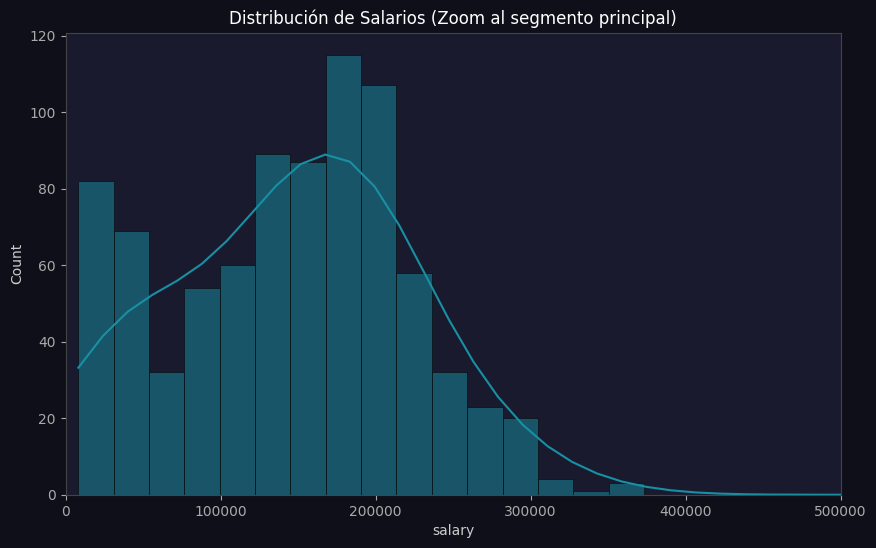

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['salary'], kde=True, color='#1890A3')
plt.xlim(0, 500000)
plt.title('Distribución de Salarios (Zoom al segmento principal)')
plt.show()

>**Analisis**

Presenta un sesgo positivo (a la derecha) muy marcado, con la gran mayoría de los salarios concentrados en la parte baja y muy pocos valores extremos muy altos.

Los outliers que observamos previamente (cercanos a 3 millones) deben ser paquetes de compensación atípicos que el modelo debe considerar.

> ## <font color='#1890A3'>**Scatterplot. Salario vs Tamano de la Empresa**</font>

**Objetivo:** Entender la relacion entre las dos variables (si la hay)

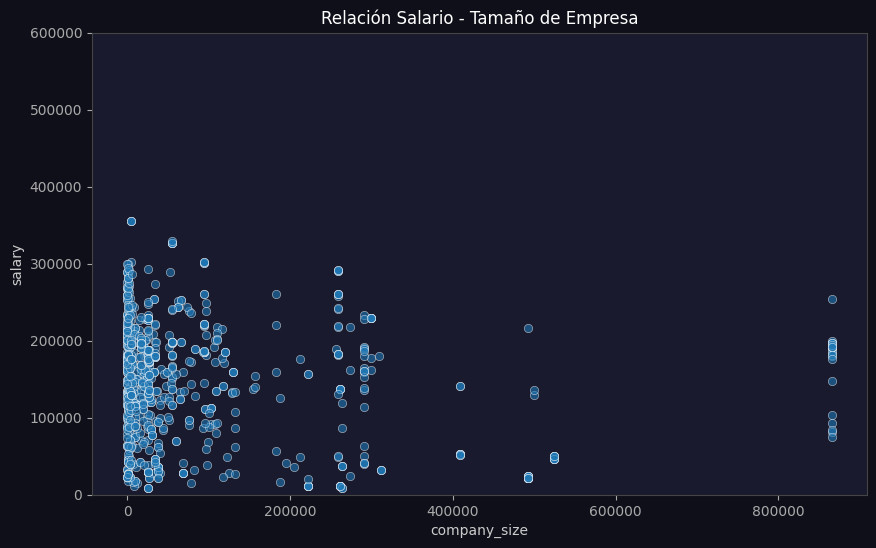

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='company_size', y='salary', data=df_clean, alpha=0.6)
plt.ylim(0, 600000)
plt.title('Relación Salario - Tamaño de Empresa')
plt.show()

> **Analisis**

No se observa una correlación lineal evidente; los salarios están dispersos independientemente de si la empresa es muy pequeña o muy grande.

La gran mayoría de datos se agrupa en empresas de menor tamaño, lo que sugiere una limitación en el dataset.



> ## <font color='#1890A3'>**Boxplot: Salario por Seniority**</font>

**Objetivo:** Conocer como se relacionan las variables


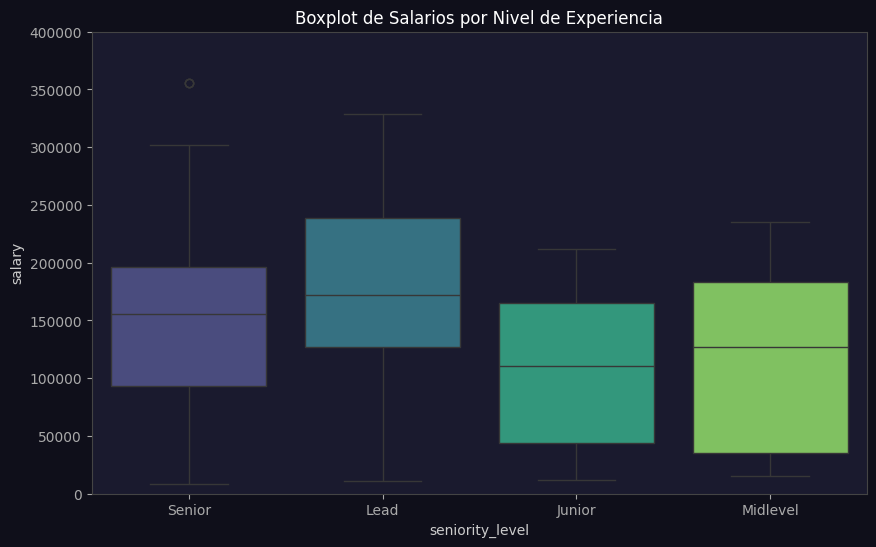

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='seniority_level', y='salary', data=df_clean, palette='viridis')
plt.ylim(0, 400000)
plt.title('Boxplot de Salarios por Nivel de Experiencia')
plt.show()

> **Analisis**

Los niveles Senior y Lead tienen medianas y rangos salariales superiores a los niveles Junior y Midlevel, como es esperado.

La presencia de los valores atípicos en Senior confirma que es ahí donde se concentran los beneficios o bonos de compensación total.

Las cajas tienen un solapamiento considerable, lo que sugiere que el "seniority" es un predictor importante, pero no el único determinante del salario.

> ## <font color='#1890A3'>**Salary por Region**</font>

**Objetivo:** Entender la distribucion del salario pro las distintas regiones


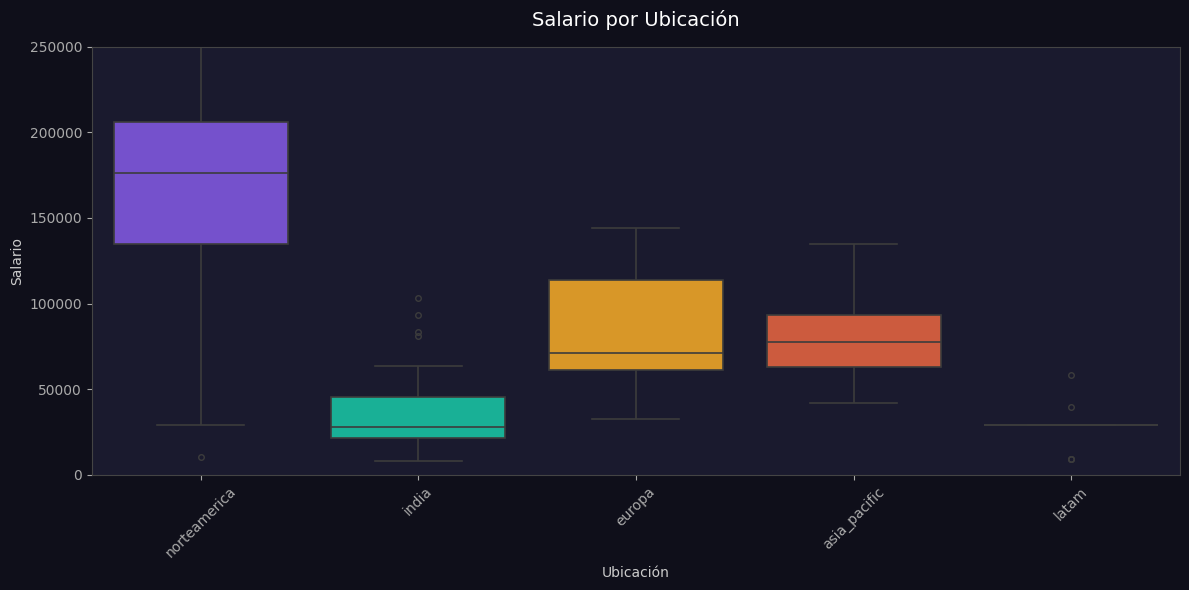

In [ ]:
mi_paleta = [PURPLE, TEAL, AMBER, RED]

plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    x='location_clean',
    y='salary',
    data=df_clean,
    hue='location_clean',
    palette=mi_paleta,
    linewidth=1.2,
    fliersize=4,
    legend=False
)
ax.set_ylim(0, 250000)
ax.set_title('Salario por Ubicación', color='white', fontsize=14, pad=15)
ax.set_xlabel('Ubicación', color='#CCC')
ax.set_ylabel('Salario', color='#CCC')

plt.xticks(rotation=45, color='#AAA')
plt.yticks(color='#AAA')

plt.tight_layout()
plt.show()

> **Analisis**

Existe una diferencia clara en los niveles salariales por región, siendo norteamerica y Europa los que tienen las remuneraciones más altas.

Latam e india muestran salarios significativamente inferiores, o menores datos, se confirma que la ubicación es una variable de alta relevancia para el modelo.


#**📊 Hallazgos y Desafios**

#**- Desafíos y Limpieza de Datos**

***Gestión de unknown:*** Gran parte de la ambigüedad en la columna location provenía de registros que solo contenían modalidades de trabajo. Tras la reclasificación, el dataset alcanzó un alto nivel de integridad.

***Desequilibrio de Clases:*** Existe una marcada disparidad en la representación geográfica. Norteamérica concentra la mayor parte de las observaciones, mientras que regiones como LATAM y Asia-Pacífico presentan volúmenes reducidos.

***Normalización de Variables:*** Se rescató información crítica mediante la columna status para evitar redundancias, asegurando que cada categoría (ubicación y modalidad) aporte información única al modelo.

#**- Características del Dataset**

***Disparidad Salarial:*** La brecha salarial entre regiones es significativa. El análisis visual permite observar que el mercado norteamericano presenta una dispersión mucho mayor y techos salariales más elevados que en otras regiones (ademas de que la mayoria de los datos provienen de esta region)

***Calidad de los Datos*** Se ha logrado estandarizar el dataset para que las variables categóricas (regiones) tengan un comportamiento predecible.

***Cantidad de Datos*** Debido a que el dataset es chico, se ha priorizado la limpieza exhaustiva sobre la imputación de valores, garantizando que el modelo final trabaje únicamente con datos reales y validados, maximizando así la precisión de las futuras predicciones salariales.

#**- Desafios para el Modelado**

***Escalamiento:*** Debido a la naturaleza exponencial de los salarios, se recomienda una transformación logarítmica durante el entrenamiento del modelo para mejorar la normalidad de los residuos.

***Consistencia:*** A pesar del desequilibrio de muestras, la calidad de los datos ha sido optimizada, permitiendo que el modelo capture las tendencias generales del mercado global sin las distorsiones causadas por etiquetas mal categorizadas.

